# Finetune BGE Embeddings on SQuAD-style Dataset

In this notebook, we finetune the `bge-large-en-v1.5` model on a custom SQuAD-format dataset.
The training format used by FlagEmbedding expects:
```
{"query": str, "pos": List[str], "neg": List[str]}
```
Where `query` = question, `pos` = [context paragraph], `neg` = [] (mined via hard negative algorithm).

In [2]:
!pip install "sentence-transformers==3.3.1" "transformers>=4.46.0" faiss-gpu "accelerate>=1.1.0" -q -U

In [3]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm
from transformers import AutoTokenizer

tqdm.pandas()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'

In [4]:
model_id     = 'BAAI/bge-large-en-v1.5'
dataset_path = '/kaggle/input/datasets/ugurhandasdemir/healtcare-ai/squad_dataset.json'

# Output directory — must be writable. Change this if running on Kaggle:
output_dir = '/kaggle/working'
#output_dir = '/home/ugo/Documents/Python/bitirememe projesi/CUSTOM_DATASET'
os.makedirs(output_dir, exist_ok=True)

# File paths (defined once, used throughout the notebook)
pretrain_path = os.path.join(output_dir, 'pretrain_data.jsonl')
finetune_path = os.path.join(output_dir, 'finetune_data.jsonl')
mined_path    = os.path.join(output_dir, 'finetune_data_minedHN.jsonl')
model_out_dir = os.path.join(output_dir, 'bge_squad_model')

print(f"dataset_path  : {dataset_path}")
print(f"output_dir    : {output_dir}")
print(f"model_out_dir : {model_out_dir}")

dataset_path  : /kaggle/input/datasets/ugurhandasdemir/healtcare-ai/squad_dataset.json
output_dir    : /kaggle/working
model_out_dir : /kaggle/working/bge_squad_model


In [5]:
# Load SQuAD-format dataset
with open(dataset_path, 'r', encoding='utf-8') as f:
    squad_data = json.load(f)

records = []
for article in squad_data['data']:
    for para in article['paragraphs']:
        context = para['context']
        for qa in para['qas']:
            if not qa['is_impossible'] and qa['answers']:
                records.append({
                    'question': qa['question'],
                    'context': context,
                })

train = pd.DataFrame(records)
print(f"Total QA pairs: {len(train)}")
print(f"Unique contexts: {train['context'].nunique()}")
train.head()

Total QA pairs: 7194
Unique contexts: 1059


,question,context
0,What is the primary objective of the study men...,Perceptions of Artiﬁcial Intelligence Among He...
1,How was the survey distributed?,Perceptions of Artiﬁcial Intelligence Among He...
2,Who were the participants in the survey?,Perceptions of Artiﬁcial Intelligence Among He...
3,What types of healthcare professionals complet...,Perceptions of Artiﬁcial Intelligence Among He...
4,What percentage of respondents reported never ...,Perceptions of Artiﬁcial Intelligence Among He...


In [6]:
def preprocess_text(x):
    x = x.lower()
    x = re.sub(r"http\S+", '', x)        # Remove URLs
    x = re.sub(r"\s+", " ", x)           # Collapse whitespace
    x = re.sub(r"\.+", ".", x)           # Collapse consecutive dots
    x = re.sub(r"\,+", ",", x)           # Collapse consecutive commas
    x = x.strip()
    return x

In [7]:
train['question'] = train['question'].apply(preprocess_text)
train['context']  = train['context'].apply(preprocess_text)

print(f"Sample question : {train['question'].iloc[0]}")
print(f"Sample context  : {train['context'].iloc[0][:200]}...")

Sample question : what is the primary objective of the study mentioned in the text?
Sample context  : perceptions of artiﬁcial intelligence among healthcare staff: a qualitative survey study simone castagno* and mohamed khalifa department of interventional radiology, royal free hospital, london, unite...


In [8]:
train.head()

,question,context
0,what is the primary objective of the study men...,perceptions of artiﬁcial intelligence among he...
1,how was the survey distributed?,perceptions of artiﬁcial intelligence among he...
2,who were the participants in the survey?,perceptions of artiﬁcial intelligence among he...
3,what types of healthcare professionals complet...,perceptions of artiﬁcial intelligence among he...
4,what percentage of respondents reported never ...,perceptions of artiﬁcial intelligence among he...


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7194 entries, 0 to 7193
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  7194 non-null   object
 1   context   7194 non-null   object
dtypes: object(2)
memory usage: 112.5+ KB


### Infer optimal max_lengths for query (question) and passage (context)

The graphs below show the token length distributions.
Based on the distribution, choose appropriate `query_max_len` and `passage_max_len` for training.

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

  0%|          | 0/7194 [00:00<?, ?it/s]

  0%|          | 0/7194 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (925 > 512). Running this sequence through the model will result in indexing errors


Question — mean:15  p90:20  p95:22  max:38
Context  — mean:257  p90:316  p95:351  max:963

→ QUERY_MAX_LEN   = 32
→ PASSAGE_MAX_LEN = 352


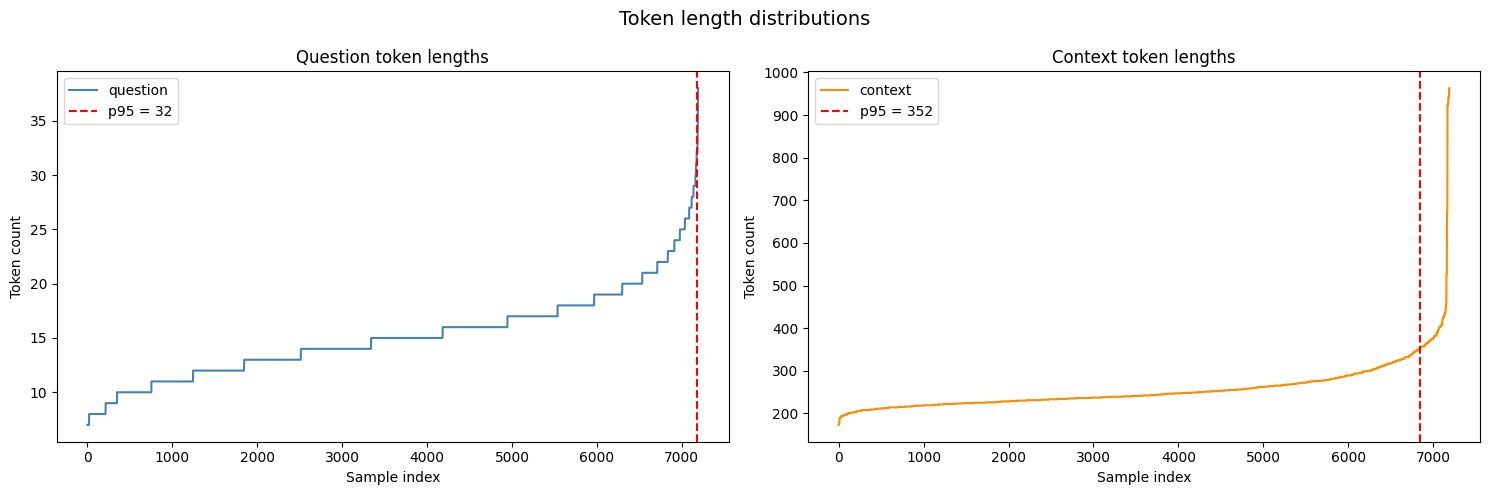

In [10]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

question_lens = train['question'].progress_apply(lambda x: len(tokenizer(x)['input_ids']))
context_lens  = train['context'].progress_apply(lambda x: len(tokenizer(x)['input_ids']))

# Compute p95 and round up to nearest multiple of 32
def round_to_32(n):
    return int(((n + 31) // 32) * 32)

QUERY_MAX_LEN   = round_to_32(int(question_lens.quantile(0.95)))
PASSAGE_MAX_LEN = round_to_32(int(context_lens.quantile(0.95)))

print(f"Question — mean:{question_lens.mean():.0f}  p90:{question_lens.quantile(0.90):.0f}  p95:{question_lens.quantile(0.95):.0f}  max:{question_lens.max()}")
print(f"Context  — mean:{context_lens.mean():.0f}  p90:{context_lens.quantile(0.90):.0f}  p95:{context_lens.quantile(0.95):.0f}  max:{context_lens.max()}")
print(f"\n→ QUERY_MAX_LEN   = {QUERY_MAX_LEN}")
print(f"→ PASSAGE_MAX_LEN = {PASSAGE_MAX_LEN}")

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle('Token length distributions', fontsize=14)

question_lens.sort_values().reset_index(drop=True).plot.line(ax=ax1, color='steelblue')
ax1.axvline(x=(question_lens <= QUERY_MAX_LEN).sum(), color='red', linestyle='--', label=f'p95 = {QUERY_MAX_LEN}')
ax1.set_title('Question token lengths')
ax1.set_xlabel('Sample index')
ax1.set_ylabel('Token count')
ax1.legend()

context_lens.sort_values().reset_index(drop=True).plot.line(ax=ax2, color='darkorange')
ax2.axvline(x=(context_lens <= PASSAGE_MAX_LEN).sum(), color='red', linestyle='--', label=f'p95 = {PASSAGE_MAX_LEN}')
ax2.set_title('Context token lengths')
ax2.set_xlabel('Sample index')
ax2.set_ylabel('Token count')
ax2.legend()

plt.tight_layout()
plt.show()

## Data format
Train data should be a json file, where each line is a dict like this:

```
{"query": str, "pos": List[str], "neg":List[str]}
```

`query` is the query, and `pos` is a list of positive texts, `neg` is a list of negative texts.
If you have no negative texts for a query, you can random sample some from the entire corpus as the negatives.

See [toy_finetune_data.jsonl](https://github.com/FlagOpen/FlagEmbedding/blob/master/examples/finetune/toy_finetune_data.jsonl) for a toy data file.

In [11]:
# pretrain_data: all unique contexts (candidate pool for hard negative mining)
unique_contexts = train['context'].drop_duplicates().tolist()
pretrain_data   = [{'text': ctx} for ctx in unique_contexts]

# finetune_data: query=question, pos=[context], neg=[] (populated by HN miner)
questions = train['question'].tolist()
contexts  = train['context'].tolist()
finetune_data = [
    {'query': q, 'pos': [c], 'neg': []}
    for q, c in zip(questions, contexts)
]

print(f"pretrain_data (unique contexts) : {len(pretrain_data)}")
print(f"finetune_data (QA pairs)        : {len(finetune_data)}")

pretrain_data (unique contexts) : 1059
finetune_data (QA pairs)        : 7194


In [12]:
finetune_data[0]

{'query': 'what is the primary objective of the study mentioned in the text?',
 'pos': ['perceptions of artiﬁcial intelligence among healthcare staff: a qualitative survey study simone castagno* and mohamed khalifa department of interventional radiology, royal free hospital, london, united kingdom objectives: the medical community is in agreement that artiﬁcial intelligence (ai) will have a radical impact on patient care in the near future. the purpose of this study is to assess the awareness of ai technologies among health professionals and to investigate their perceptions toward ai applications in medicine. design: a web-based google forms survey was distributed via the royal free london nhs foundation trust e-newsletter. setting: only staff working at the nhs foundation trust received an invitation to complete the online questionnaire. participants: 98 healthcare professionals out of 7,538 (response rate 1.3%; ci 95%; margin of error 9.64%) completed the survey, including medical do

In [13]:
with open(pretrain_path, 'w', encoding='utf-8') as f:
    for entry in pretrain_data:
        json.dump(entry, f, ensure_ascii=False)
        f.write('\n')

with open(finetune_path, 'w', encoding='utf-8') as f:
    for entry in finetune_data:
        json.dump(entry, f, ensure_ascii=False)
        f.write('\n')

print(f"Saved → {pretrain_path}  ({len(pretrain_data)} lines)")
print(f"Saved → {finetune_path}  ({len(finetune_data)} lines)")

Saved → /kaggle/working/pretrain_data.jsonl  (1059 lines)
Saved → /kaggle/working/finetune_data.jsonl  (7194 lines)


## Hard Negative Mining (FAISS)

We use the base BGE model to encode all queries and candidate passages, build a FAISS index,
retrieve the top-k most similar candidates for each query, then sample negatives
(excluding the actual positive passage).

In [14]:
import gc
import faiss
from sentence_transformers import SentenceTransformer

gc.collect()
torch.cuda.empty_cache()

st_model = SentenceTransformer(model_id)
st_model.max_seq_length = max(QUERY_MAX_LEN, PASSAGE_MAX_LEN)

# Encode candidates (unique contexts)
candidate_texts = [e["text"] for e in pretrain_data]
print(f"Encoding {len(candidate_texts)} candidate passages...")
candidate_embs = st_model.encode(candidate_texts, normalize_embeddings=True,
                                  show_progress_bar=True, batch_size=16,
                                  convert_to_numpy=True)

# Encode queries
query_texts = [e["query"] for e in finetune_data]
print(f"Encoding {len(query_texts)} queries...")
query_embs = st_model.encode(query_texts, normalize_embeddings=True,
                              show_progress_bar=True, batch_size=16,
                              convert_to_numpy=True)

# Free the encoder before building the index
del st_model
gc.collect()
torch.cuda.empty_cache()

# FAISS on CPU — 1059 vectors is trivial
dim = candidate_embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(candidate_embs.astype("float32"))

scores, indices = index.search(query_embs.astype("float32"), 100)

NEGATIVE_NUMBER = 15
RANGE_START, RANGE_END = 1, 100

finetune_data_minedHN = []
for i, entry in enumerate(tqdm(finetune_data, desc="Mining negatives")):
    pos_set = set(entry["pos"])
    neg_candidates = []
    for j in range(RANGE_START, min(RANGE_END, len(indices[i]))):
        cand_text = candidate_texts[indices[i][j]]
        if cand_text not in pos_set:
            neg_candidates.append(cand_text)
    if len(neg_candidates) > NEGATIVE_NUMBER:
        sampled = list(np.random.choice(neg_candidates, NEGATIVE_NUMBER, replace=False))
    else:
        sampled = neg_candidates
    finetune_data_minedHN.append({
        "query": entry["query"],
        "pos": entry["pos"],
        "neg": sampled,
    })

del index, candidate_embs, query_embs
gc.collect()
torch.cuda.empty_cache()

print(f"Mined hard negatives for {len(finetune_data_minedHN)} entries")
print(f"Avg negatives per query: {np.mean([len(e['neg']) for e in finetune_data_minedHN]):.1f}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

Encoding 7194 queries...


Batches:   0%|          | 0/450 [00:00<?, ?it/s]

Mining negatives:   0%|          | 0/7194 [00:00<?, ?it/s]

Mined hard negatives for 7194 entries
Avg negatives per query: 15.0


In [15]:
finetune_data_minedHN[0]    # negs are now populated

{'query': 'what is the primary objective of the study mentioned in the text?',
 'pos': ['perceptions of artiﬁcial intelligence among healthcare staff: a qualitative survey study simone castagno* and mohamed khalifa department of interventional radiology, royal free hospital, london, united kingdom objectives: the medical community is in agreement that artiﬁcial intelligence (ai) will have a radical impact on patient care in the near future. the purpose of this study is to assess the awareness of ai technologies among health professionals and to investigate their perceptions toward ai applications in medicine. design: a web-based google forms survey was distributed via the royal free london nhs foundation trust e-newsletter. setting: only staff working at the nhs foundation trust received an invitation to complete the online questionnaire. participants: 98 healthcare professionals out of 7,538 (response rate 1.3%; ci 95%; margin of error 9.64%) completed the survey, including medical do

## Train

We fine-tune the BGE model using `sentence-transformers` with `MultipleNegativesRankingLoss`
(InfoNCE / contrastive loss). In-batch negatives are used automatically in addition to the
mined hard negatives.

**Key arguments:**
- `per_device_train_batch_size`: larger batch → more in-batch negatives → better performance
- `learning_rate`: 2e-5 recommended for bge-large
- `num_train_epochs`: 3 epochs is usually sufficient
- `fp16`: enable mixed precision for speed

In [16]:
import gc, os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from transformers import TrainerCallback

gc.collect()
torch.cuda.empty_cache()

model = SentenceTransformer(model_id)
model.max_seq_length = max(QUERY_MAX_LEN, PASSAGE_MAX_LEN)
model[0].auto_model.gradient_checkpointing_enable()
print(f"model.max_seq_length = {model.max_seq_length}")

train_examples = []
for entry in finetune_data_minedHN:
    q   = entry["query"]
    pos = entry["pos"][0]
    neg = entry["neg"][0] if entry["neg"] else None
    if neg is not None:
        train_examples.append(InputExample(texts=[q, pos, neg]))
    else:
        train_examples.append(InputExample(texts=[q, pos]))

print(f"Training examples: {len(train_examples)}")

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)
train_loss = losses.MultipleNegativesRankingLoss(model)

# Capture losses in-memory so we can plot even if trainer_state.json is missing
loss_log = []
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            loss_log.append({'step': state.global_step, 'loss': logs['loss']})

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=50,
    output_path=model_out_dir,
    use_amp=True,
    optimizer_params={'lr': 2e-5},
    show_progress_bar=True,
    callback=LossLogger(),
)

print(f"Model saved to: {model_out_dir}")
print(f"Logged {len(loss_log)} loss entries")

del model, train_dataloader, train_examples
gc.collect()
torch.cuda.empty_cache()


model.max_seq_length = 352
Training examples: 7194


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]


Step,Training Loss
500,0.663700
1000,0.390700
1500,0.221000
2000,0.153200
2500,0.115100


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Model saved to: /kaggle/working/bge_squad_model
Logged 0 loss entries


## Results

### 1 — Training Loss

In [17]:
import glob
import numpy as np

candidates = sorted(glob.glob(os.path.join(model_out_dir, '**', 'trainer_state.json'), recursive=True))

if candidates:
    trainer_state_path = candidates[-1]
    print(f"Loading: {trainer_state_path}")
    with open(trainer_state_path, 'r') as f:
        trainer_state = json.load(f)
    loss_entries = [e for e in trainer_state['log_history'] if 'loss' in e]
    steps  = [e['step'] for e in loss_entries]
    losses = [e['loss'] for e in loss_entries]
elif 'loss_log' in globals() and loss_log:
    print("Using in-memory loss_log from training callback")
    steps  = [e['step'] for e in loss_log]
    losses = [e['loss'] for e in loss_log]
else:
    print("No trainer_state.json and no in-memory loss_log — skipping loss curve.")
    print("Re-run the training cell (it now logs losses to `loss_log`) to capture the curve.")
    steps, losses = [], []

if losses:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, losses, marker='o', markersize=3, linewidth=1.5, color='steelblue', label='Train loss')
    ax.set_title('Training Loss Curve', fontsize=14)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Final loss  : {losses[-1]:.4f}")
    print(f"Best loss   : {min(losses):.4f}  (step {steps[losses.index(min(losses))]})")
    print(f"Total steps : {len(losses)}")


No trainer_state.json and no in-memory loss_log — skipping loss curve.
Re-run the training cell (it now logs losses to `loss_log`) to capture the curve.


### 2 — Similarity Distribution: Base vs Fine-tuned

For each QA pair we compute cosine similarity between the question embedding and its correct context embedding.
We then compare the distributions for the base model and the fine-tuned model.

In [18]:
import torch
import torch.nn.functional as F
from transformers import AutoModel

EVAL_SAMPLE = 300   # number of QA pairs to evaluate (increase for a more precise estimate)

# --- helpers ----------------------------------------------------------------

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * input_mask_expanded).sum(1) / input_mask_expanded.sum(1).clamp(min=1e-9)

def get_embeddings(texts, model, tokenizer, batch_size=32, max_len=512, device='cuda'):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model(**enc)
        emb = mean_pooling(out, enc['attention_mask'])
        emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
    return torch.cat(all_embs, dim=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sample eval pairs
eval_df = train.sample(EVAL_SAMPLE, random_state=42).reset_index(drop=True)
eval_questions = eval_df['question'].tolist()
eval_contexts  = eval_df['context'].tolist()

# --- Load models ------------------------------------------------------------

print("Loading base model...")
base_model = AutoModel.from_pretrained(model_id).to(device).eval()

print("Loading fine-tuned model...")
ft_model = AutoModel.from_pretrained(model_out_dir).to(device).eval()

ft_tokenizer = AutoTokenizer.from_pretrained(model_out_dir)
base_tokenizer = AutoTokenizer.from_pretrained(model_id)

Loading base model...
Loading fine-tuned model...


In [19]:
# Compute embeddings
print("Computing base model embeddings...")
base_q_embs = get_embeddings(eval_questions, base_model, base_tokenizer, max_len=QUERY_MAX_LEN,   device=device)
base_c_embs = get_embeddings(eval_contexts,  base_model, base_tokenizer, max_len=PASSAGE_MAX_LEN, device=device)

print("Computing fine-tuned model embeddings...")
ft_q_embs = get_embeddings(eval_questions, ft_model, ft_tokenizer, max_len=QUERY_MAX_LEN,   device=device)
ft_c_embs = get_embeddings(eval_contexts,  ft_model, ft_tokenizer, max_len=PASSAGE_MAX_LEN, device=device)

# Positive cosine similarities (diagonal = correct pair)
base_pos_sims = (base_q_embs * base_c_embs).sum(dim=1).numpy()
ft_pos_sims   = (ft_q_embs   * ft_c_embs).sum(dim=1).numpy()

# Negative cosine similarities (random shuffled pairs)
rng = np.random.default_rng(42)
shuffle_idx = rng.permutation(len(eval_questions))
base_neg_sims = (base_q_embs * base_c_embs[shuffle_idx]).sum(dim=1).numpy()
ft_neg_sims   = (ft_q_embs   * ft_c_embs[shuffle_idx]).sum(dim=1).numpy()

print(f"\nBase model  — pos: {base_pos_sims.mean():.4f} ± {base_pos_sims.std():.4f}  |  neg: {base_neg_sims.mean():.4f} ± {base_neg_sims.std():.4f}")
print(f"Fine-tuned  — pos: {ft_pos_sims.mean():.4f}   ± {ft_pos_sims.std():.4f}    |  neg: {ft_neg_sims.mean():.4f}   ± {ft_neg_sims.std():.4f}")

Computing base model embeddings...
Computing fine-tuned model embeddings...

Base model  — pos: 0.7107 ± 0.0887  |  neg: 0.5930 ± 0.0770
Fine-tuned  — pos: 0.5994   ± 0.0817    |  neg: 0.1268   ± 0.0973


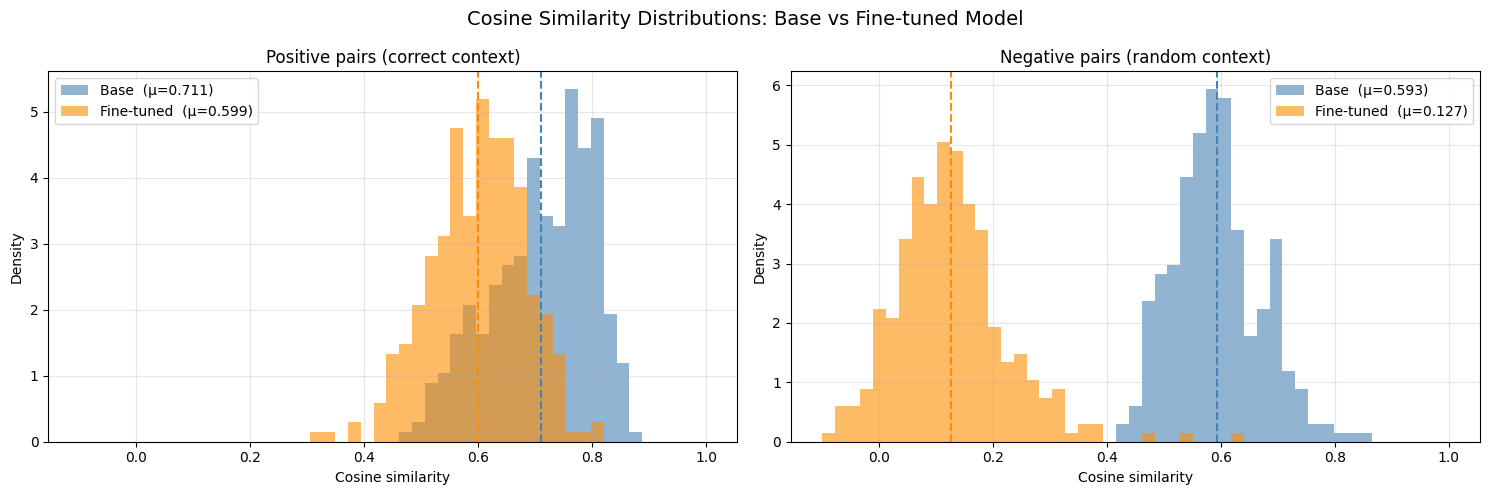

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Cosine Similarity Distributions: Base vs Fine-tuned Model', fontsize=14)

bins = np.linspace(-0.1, 1.0, 50)

for ax, (base_sims, ft_sims, label) in zip(axes, [
    (base_pos_sims, ft_pos_sims, 'Positive pairs (correct context)'),
    (base_neg_sims, ft_neg_sims, 'Negative pairs (random context)'),
]):
    ax.hist(base_sims, bins=bins, alpha=0.6, color='steelblue', label=f'Base  (μ={base_sims.mean():.3f})', density=True)
    ax.hist(ft_sims,   bins=bins, alpha=0.6, color='darkorange', label=f'Fine-tuned  (μ={ft_sims.mean():.3f})', density=True)
    ax.axvline(base_sims.mean(), color='steelblue',  linestyle='--', linewidth=1.5)
    ax.axvline(ft_sims.mean(),   color='darkorange', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel('Cosine similarity')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3 — Retrieval Accuracy @ k (Recall@k)

For each question, we rank all unique contexts by cosine similarity and check whether the correct context appears in the top-k results.

Corpus size: 262 unique contexts
Encoding corpus (base)...
Encoding corpus (fine-tuned)...

k            Base   Fine-tuned        Δ
--------------------------------------
@1          0.520        0.873   +0.353
@3          0.637        0.947   +0.310
@5          0.683        0.970   +0.287
@10         0.747        0.990   +0.243
@20         0.803        1.000   +0.197


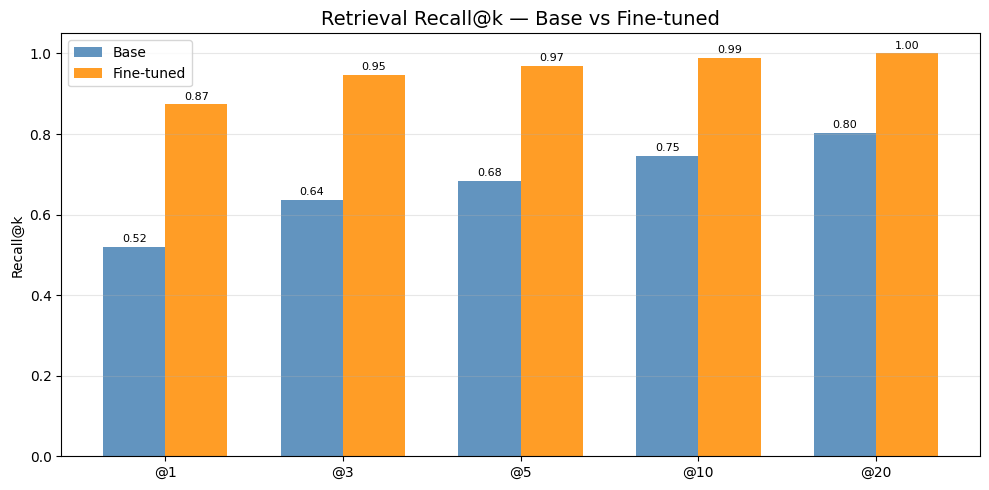

In [21]:
K_VALUES = [1, 3, 5, 10, 20]

# Build corpus from unique contexts in eval set
corpus_texts = eval_df['context'].unique().tolist()
corpus_map   = {ctx: i for i, ctx in enumerate(corpus_texts)}

print(f"Corpus size: {len(corpus_texts)} unique contexts")

# Encode corpus with both models
print("Encoding corpus (base)...")
base_corpus_embs = get_embeddings(corpus_texts, base_model, base_tokenizer, max_len=PASSAGE_MAX_LEN, device=device)
print("Encoding corpus (fine-tuned)...")
ft_corpus_embs   = get_embeddings(corpus_texts, ft_model,   ft_tokenizer,   max_len=PASSAGE_MAX_LEN, device=device)

def recall_at_k(q_embs, c_embs, correct_indices, k_values):
    scores = q_embs @ c_embs.T   # (N, C)
    results = {}
    for k in k_values:
        top_k = scores.topk(k, dim=1).indices.numpy()
        hits  = sum(correct_indices[i] in top_k[i] for i in range(len(correct_indices)))
        results[k] = hits / len(correct_indices)
    return results

correct_idx = [corpus_map[ctx] for ctx in eval_df['context'].tolist()]

base_recall = recall_at_k(base_q_embs, base_corpus_embs, correct_idx, K_VALUES)
ft_recall   = recall_at_k(ft_q_embs,   ft_corpus_embs,   correct_idx, K_VALUES)

print(f"\n{'k':<6} {'Base':>10} {'Fine-tuned':>12} {'Δ':>8}")
print('-' * 38)
for k in K_VALUES:
    delta = ft_recall[k] - base_recall[k]
    print(f"@{k:<5} {base_recall[k]:>10.3f} {ft_recall[k]:>12.3f} {delta:>+8.3f}")

# Bar chart
x   = np.arange(len(K_VALUES))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars_base = ax.bar(x - w/2, [base_recall[k] for k in K_VALUES], w, label='Base',       color='steelblue',  alpha=0.85)
bars_ft   = ax.bar(x + w/2, [ft_recall[k]   for k in K_VALUES], w, label='Fine-tuned', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'@{k}' for k in K_VALUES])
ax.set_ylabel('Recall@k')
ax.set_title('Retrieval Recall@k — Base vs Fine-tuned', fontsize=14)
ax.legend()
ax.set_ylim(0, 1.05)
ax.bar_label(bars_base, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars_ft,   fmt='%.2f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()